# Import Libraries

In [40]:
import numpy as np
import cvxpy as cp
import sympy as sp
from sympy.physics.vector import dynamicsymbols
from scipy.integrate import solve_ivp 
import matplotlib.pyplot as plt

# IEEE 14 bus network 
# to get test system
from pypower.api import case14, runpf, printpf, makeYbus
from pypower.idx_bus import *
from pypower.idx_brch import *
from pypower.idx_gen import *

# Helper functions
import helper_functions.inner_loop as il
import helper_functions.optimal_controller as oc
import helper_functions.multiple_inverter as mc
import helper_functions.plotting as plot

# Text display
from IPython.display import display, HTML, Math

# Initialize pretty printing with MathJax
sp.init_printing(use_latex="mathjax")

# Configure plot parameters
plt.rcParams.update({"font.size": 12, "font.family": "serif"})
dflt_figsize = (10.0, 6.0)
plt.rcParams['figure.figsize'] = dflt_figsize
plt.rcParams['figure.dpi'] = 200 
%matplotlib inline

# A. Setpoint change (droop comparison)

## A.1 Outer Loop Only

In [41]:
# copy from before

## A.2 Include inner loop dynamics

In [43]:
S_rated = 1200 # VA/W
S_base = S_rated # for per unit (3 phase)
v_nom_val = 120 # V
V_base = v_nom_val # for per unit (LN, RMS)
f_nom_val = 60 # Hz
omega_nom_val = 2 * np.pi * f_nom_val # rad/s
r_f_val = 0.8 # Ohm (R value)
l_f_val = 1.5e-3 # H (L value)
i_nom_val = S_rated/(3*v_nom_val) 
I_base = S_base/(3*V_base) # for per unit (phase, RMS)
Z_base = V_base / I_base # for per unit

Imag_lim_val = i_nom_val
# Filter and line parameters
r_i_val, r_g_val = 0.4, 0.9
l_i_val, l_g_val =  1.5e-3, 2e-3
c_val = 10e-7
L = l_i_val+l_g_val
R = r_i_val+r_g_val
Vg = np.array([v_nom_val,0])
starttime = 0.05
endtime = 1

### P,Q example

/Users/laurenstreitmatter/GitHub_Repos/Optimal-Safe-Converter-Control/.venv/lib/python3.9/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


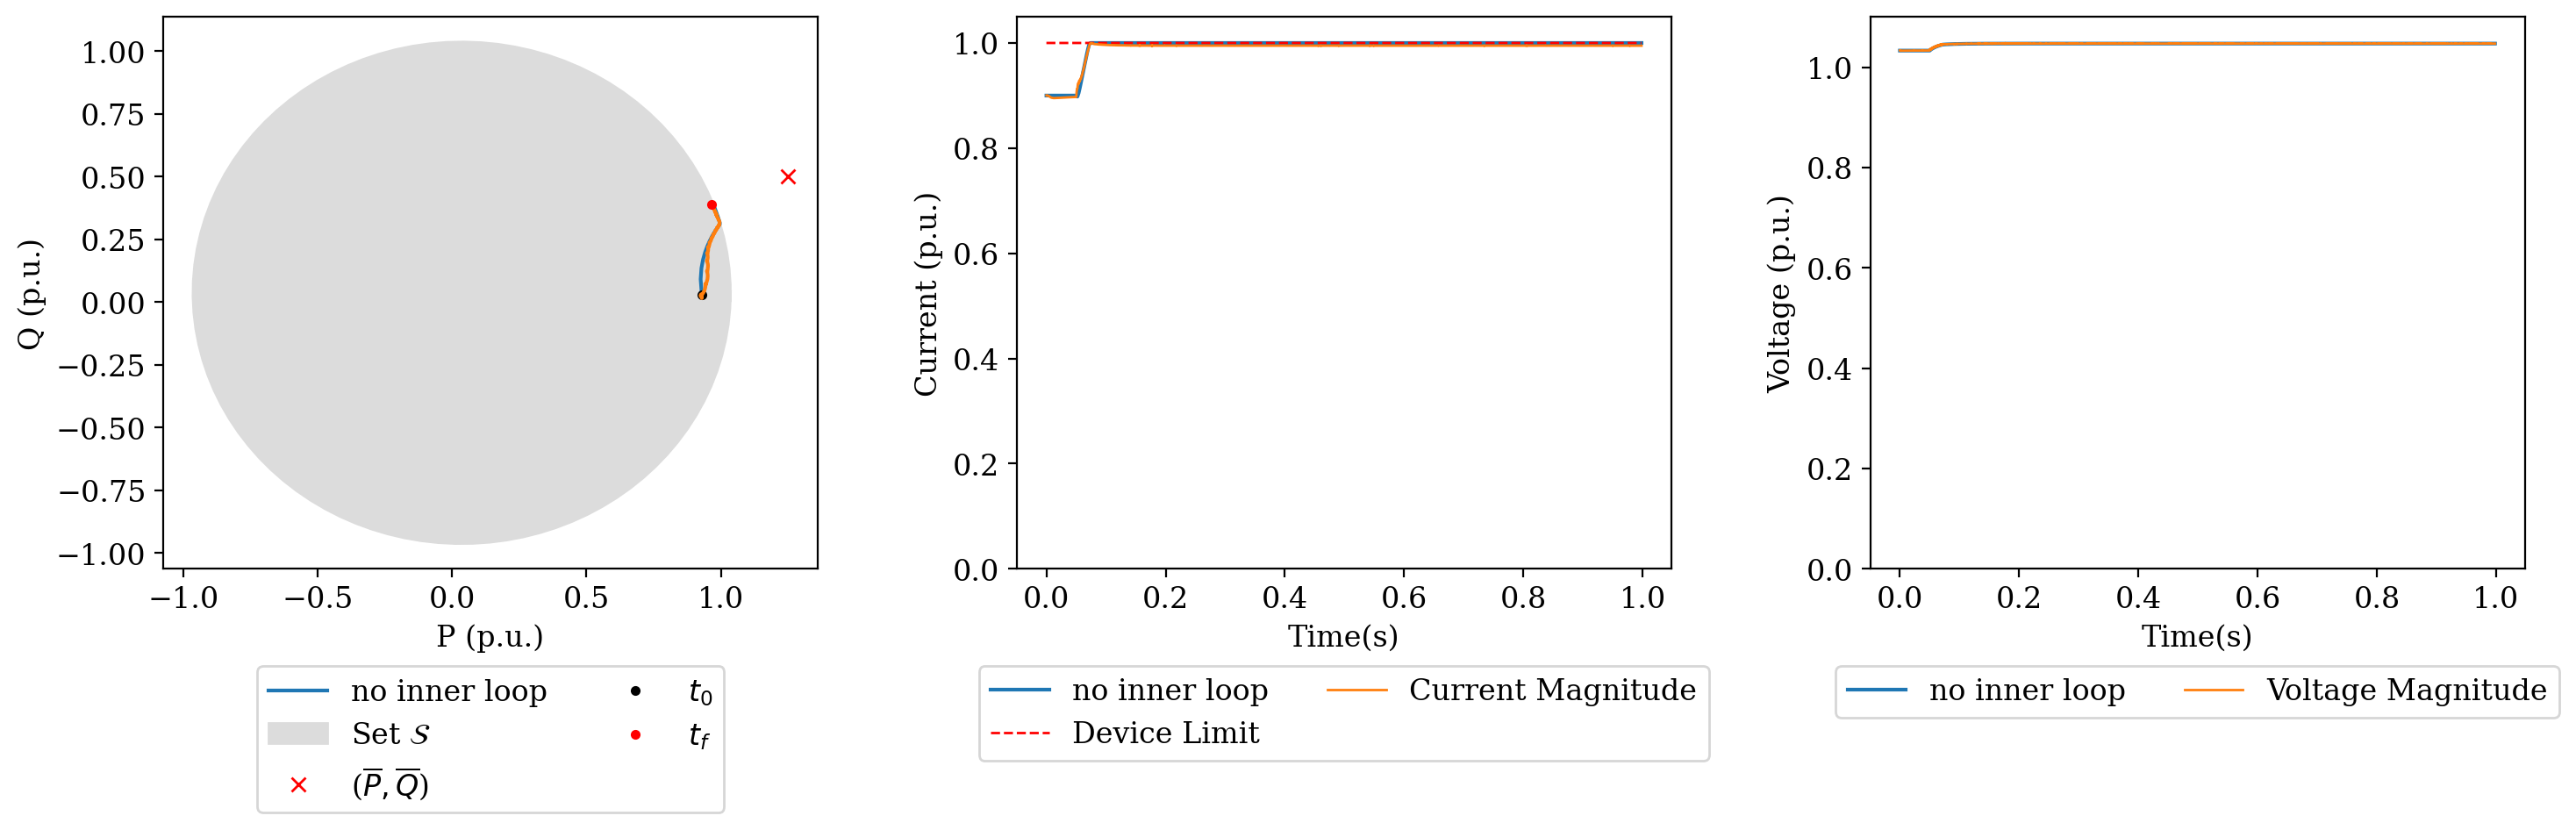

In [5]:
new_setpoints = [1500,600]
x0 = np.array([3.0,0])

freq_outer = 500
freq_vol = 2000
freq_cur = 10000


ts_inner, Idq_of_t_inner,Vdq_of_t_inner,var1_of_t_inner,var2_of_t_inner = oc.oc_setpoint_change_with_il(new_setpoints, var_names, x0, 
                               r_i_val, l_i_val, r_g_val, l_g_val, c_val, Vg,
                               Imag_lim_val,omega_nom_val,
                               rho=0.01,alpha=0.00001, dt=1/freq_outer, 
                               starttime=starttime, endtime=endtime,
                               freq_cur=freq_cur, freq_vol=freq_vol)

ts, Idq_of_t,Vdq_of_t,var1_of_t,var2_of_t = oc.oc_setpoint_change(new_setpoints, var_names, x0, R, L, Vg,
                        Imag_lim_val,omega_nom_val,
                        rho=0.01,alpha=0.00001, dt=1/freq_outer, 
                        starttime=starttime, endtime=endtime)

# Convert to per unit for presentation of results
new_setpoints_pu = [new_setpoints[0]/S_base, new_setpoints[1]/S_base]
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,5))
ax1.plot(var1_of_t/S_base, var2_of_t/S_base, label="no inner loop")
ax2.plot(ts, np.linalg.norm(Idq_of_t,axis=0)/I_base,label="no inner loop")
ax3.plot(ts, np.linalg.norm(Vdq_of_t,axis=0)/V_base,label="no inner loop")
plot.plot_S(np.vstack([var1_of_t_inner/S_base,var2_of_t_inner/S_base]).T, new_setpoints_pu,var_names, 
           Imag_lim_val/I_base,v_nom_val/V_base,L/Z_base,R/Z_base,omega_nom_val, 
           units = ["p.u.","p.u."], ax = ax1, pu=True)
plot.plot_magnitude_over_time(ts_inner, Idq_of_t_inner/I_base, current_lim = Imag_lim_val/I_base,ax = ax2,include_dq=False,var_name="Current (p.u.)")
plot.plot_magnitude_over_time(ts_inner, Vdq_of_t_inner/V_base,ax = ax3,include_dq=False,var_name="Voltage (p.u.)")

plt.tight_layout()



### $P,V^2$ example

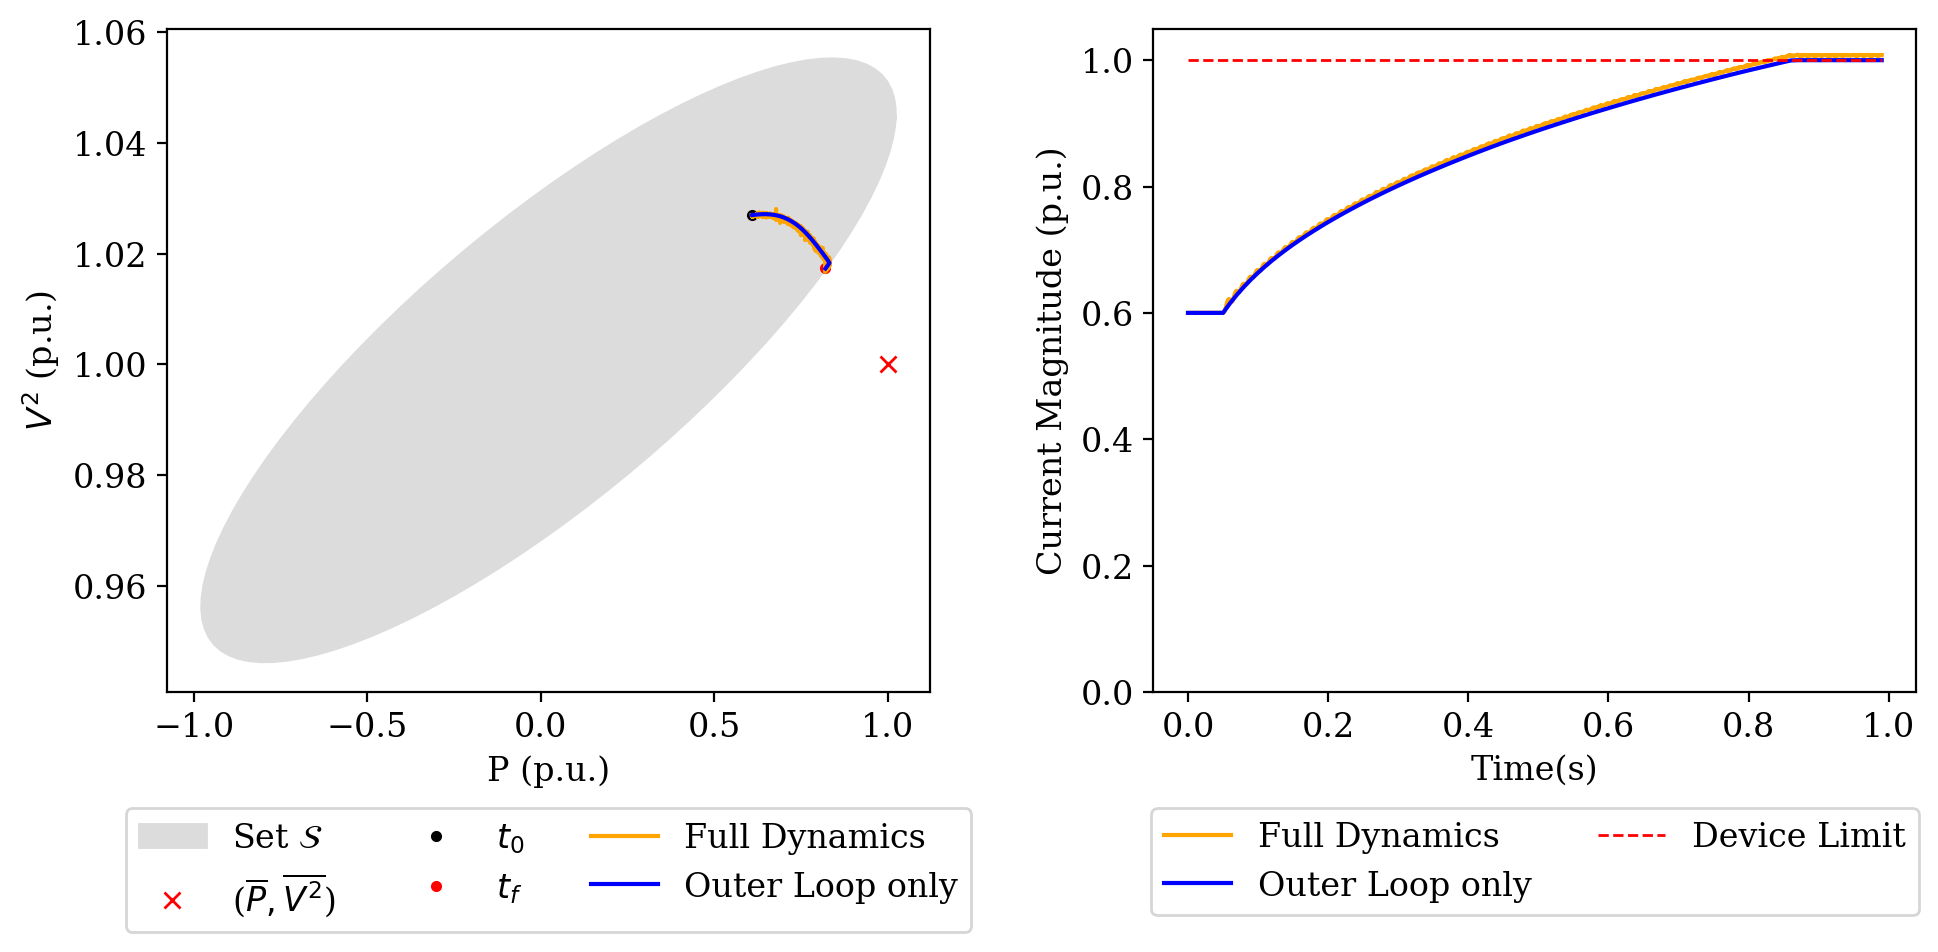

In [70]:
var_names = ["P",r"$V^2$"]
new_setpoints = [1200,120**2]
x0 = np.array([2,0])
freq_outer = 100
freq_vol = 800
freq_cur = 3000
alpha = 1e-5

r_i_val = 0.2
r_g_val = 0.6

l_i_val = 0.1e-3
l_g_val = 1.4e-3

R = r_i_val + r_g_val
L = l_i_val + l_g_val

ts_inner, Idq_of_t_inner,Vdq_of_t_inner,var1_of_t_inner,var2_of_t_inner = oc.oc_setpoint_change_with_il(new_setpoints, var_names, x0, 
                               r_i_val, l_i_val, r_g_val, l_g_val, c_val, Vg,
                               Imag_lim_val,omega_nom_val,
                               rho=0.01,alpha=alpha, dt=1/freq_outer, 
                               starttime=starttime, endtime=endtime,
                               freq_cur=freq_cur, freq_vol=freq_vol)

ts, Idq_of_t,Vdq_of_t,var1_of_t,var2_of_t = oc.oc_setpoint_change(new_setpoints, var_names, x0, R, L, Vg,
                        Imag_lim_val,omega_nom_val,
                        rho=0.01,alpha=alpha, dt=1/freq_outer, 
                        starttime=starttime, endtime=endtime)


# Convert to per unit for presentation of results
new_setpoints_pu = [new_setpoints[0]/S_base, new_setpoints[1]/V_base**2]
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))

units = ["p.u.","p.u."]
trajectory_data = np.vstack([var1_of_t_inner/S_base,var2_of_t_inner/V_base**2]).T
region_data = plot.set_S(var_names,Imag_lim_val/I_base,v_nom_val/V_base,L/Z_base,R/Z_base,omega_nom_val,pu=True)
ax1.fill(region_data[:,0],region_data[:,1],c="gainsboro",label=r"Set $\mathcal{S}$")
ax1.plot(new_setpoints_pu[0],new_setpoints_pu[1],"rx",label=fr"($\overline{{{var_names[0]}}},\overline{{{var_names[1].strip('$')}}}$)")
ax1.plot(trajectory_data[0,0],trajectory_data[0,1],"k.",label=r"$t_0$")
ax1.plot(trajectory_data[-1,0],trajectory_data[-1,1],"r.",label=r"$t_f$")
ax1.plot(trajectory_data[:,0], trajectory_data[:,1], label="Full Dynamics",c="orange")
ax1.plot(var1_of_t/S_base, var2_of_t/V_base**2, c="blue", label="Outer Loop only")
ax1.set_xlabel(f"{var_names[0]} ({units[0]})")
ax1.set_ylabel(f"{var_names[1]} ({units[1]})")
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)


ax2.plot(ts_inner, np.linalg.norm(Idq_of_t_inner/I_base,axis=0),label="Full Dynamics",c="orange")
ax2.plot(ts, np.linalg.norm(Idq_of_t,axis=0)/I_base,label="Outer Loop only",c="blue")
ax2.plot(ts, (Imag_lim_val/I_base) * np.ones(len(ts)),"r--",linewidth=1,label="Device Limit")
ax2.set_ylim(bottom=0, top=1.05*(Imag_lim_val/I_base))
ax2.set_ylabel("Current Magnitude (p.u.)")
ax2.set_xlabel("Time(s)")
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()



# B. Step change in grid voltage (droop comparison)

In [1]:
# copy from before

# C. Setpoint change in 14 bus (reduced) network

### 1. Load 14 bus test system and run powerflow

In [25]:
net14 = case14()
base_mva = net14["baseMVA"]
nb = net14["bus"].shape[0]
nbr = net14["branch"].shape[0]
# Initialize "inverters" at non-zero power before solving powerflow
net14["gen"][:,PG] = np.array([60,90,50,50,50])

# Find equilibrium point (run power flow) to initialize simulation
pf_result, success = runpf(net14)

PYPOWER Version 5.1.18, 10-Apr-2025 -- AC Power Flow (Newton)


Newton's method power flow converged in 3 iterations.

Converged in 0.01 seconds
|     System Summary                                                           |

How many?                How much?              P (MW)            Q (MVAr)
---------------------    -------------------  -------------  -----------------
Buses             14     Total Gen Capacity     772.4         -52.0 to 148.0
Generators         5     On-line Capacity       772.4         -52.0 to 148.0
Committed Gens     5     Generation (actual)    261.1              40.6
Loads             11     Load                   259.0              73.5
  Fixed           11       Fixed                259.0              73.5
  Dispatchable     0       Dispatchable           0.0 of 0.0        0.0
Shunts             1     Shunt (inj)             -0.0              21.3
Branches          20     Losses (I^2 * Z)         2.10             12.98
Transformers       3     Branch 

### 2. Choose inverter filter parameters

In [26]:
inverter_bus_ids = np.array(net14["gen"][:,GEN_BUS],dtype=int)
slack_id = inverter_bus_ids[0]
inverter_bus_ids = inverter_bus_ids[1:]
filter_xs = np.ones(len(inverter_bus_ids)) * 0.1 # np.random.uniform(0.08, 0.12, 5) # in per unit
filter_rs = np.ones(len(inverter_bus_ids)) * 0.01 # np.random.uniform(0.08, 0.2,5) * filter_xs # in per unit, slightly larger resistances than reactances


### 3. Construct Ybus matrix

In [27]:
Ybus = mc.create_Ybus(net14, pf_result)
Ybus_KRONdq, Y_slackdq = mc.Kron_reduce(Ybus, slack_id-1, inverter_bus_ids-1)

### 4. Simulate

#### Example 1: Set all voltage magnitudes to 1, keep power constant

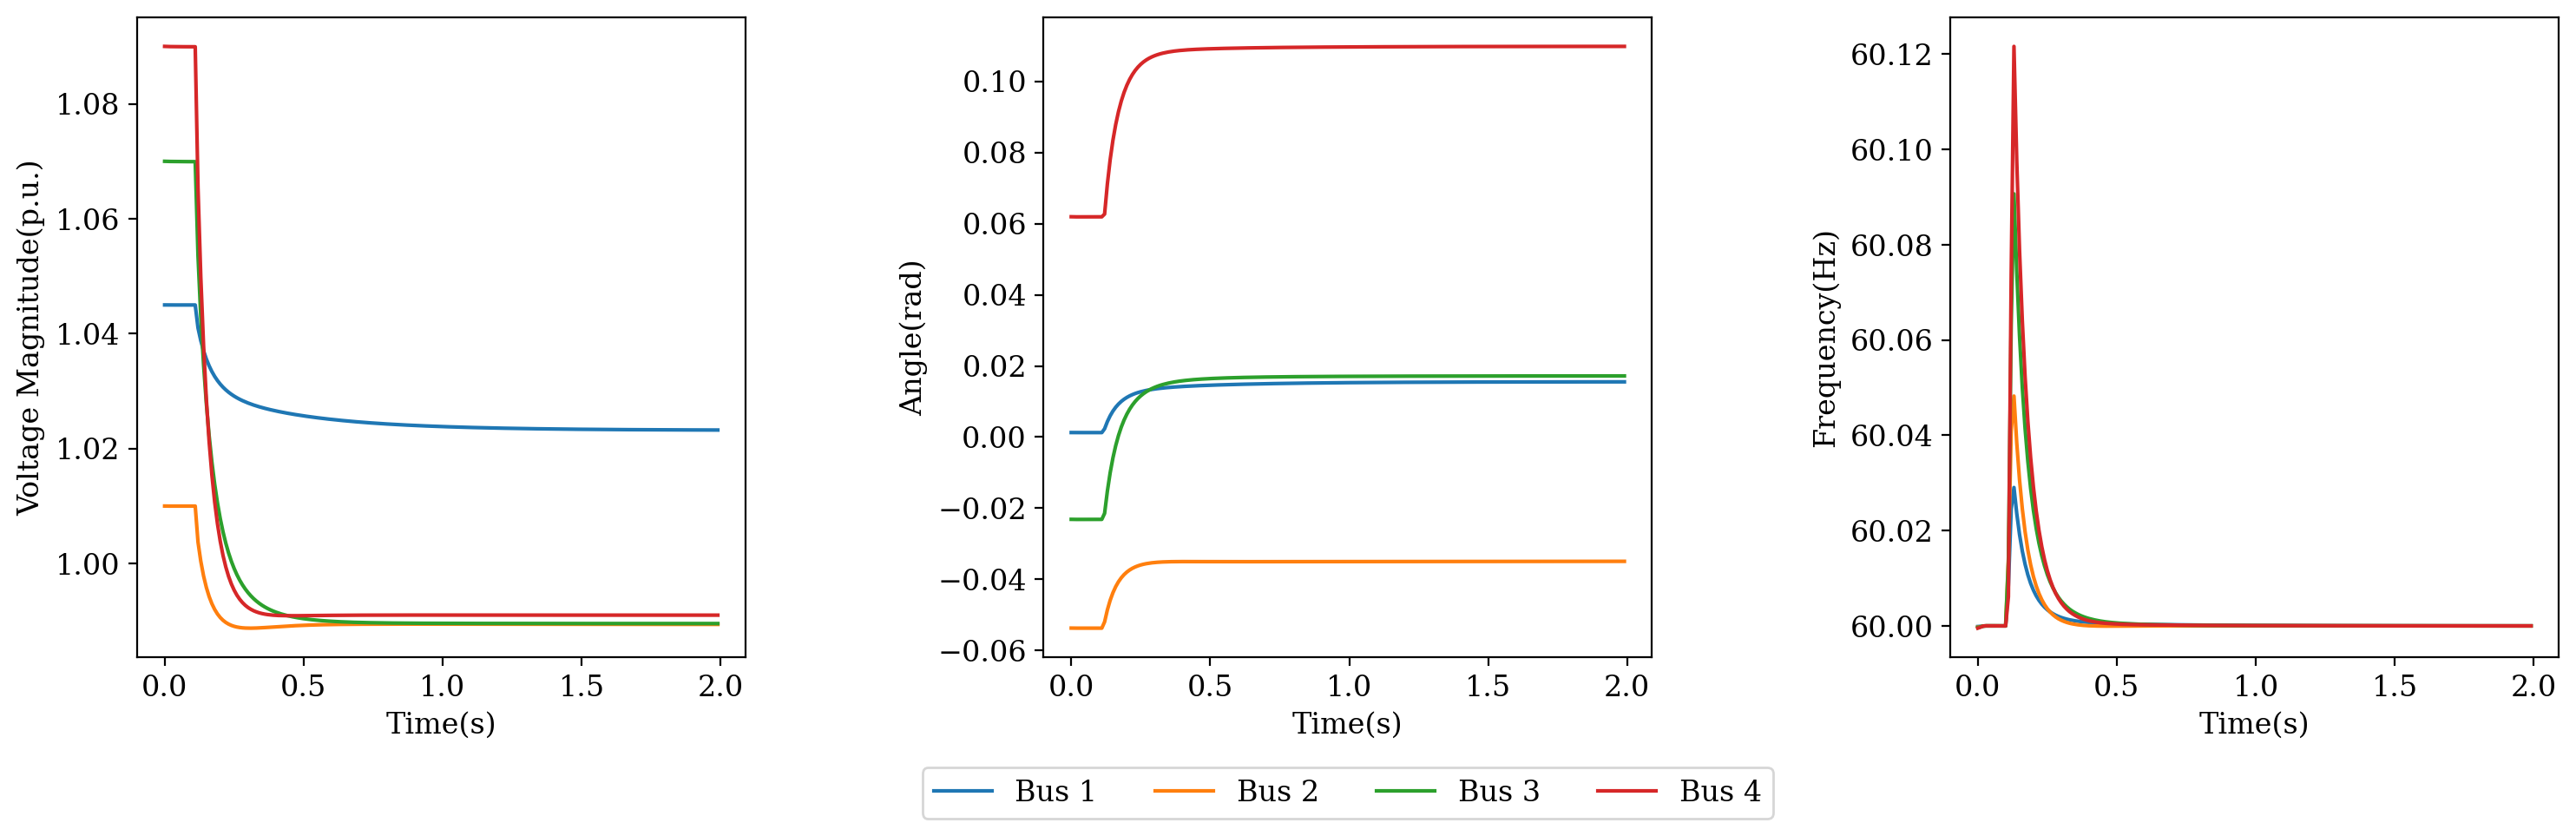

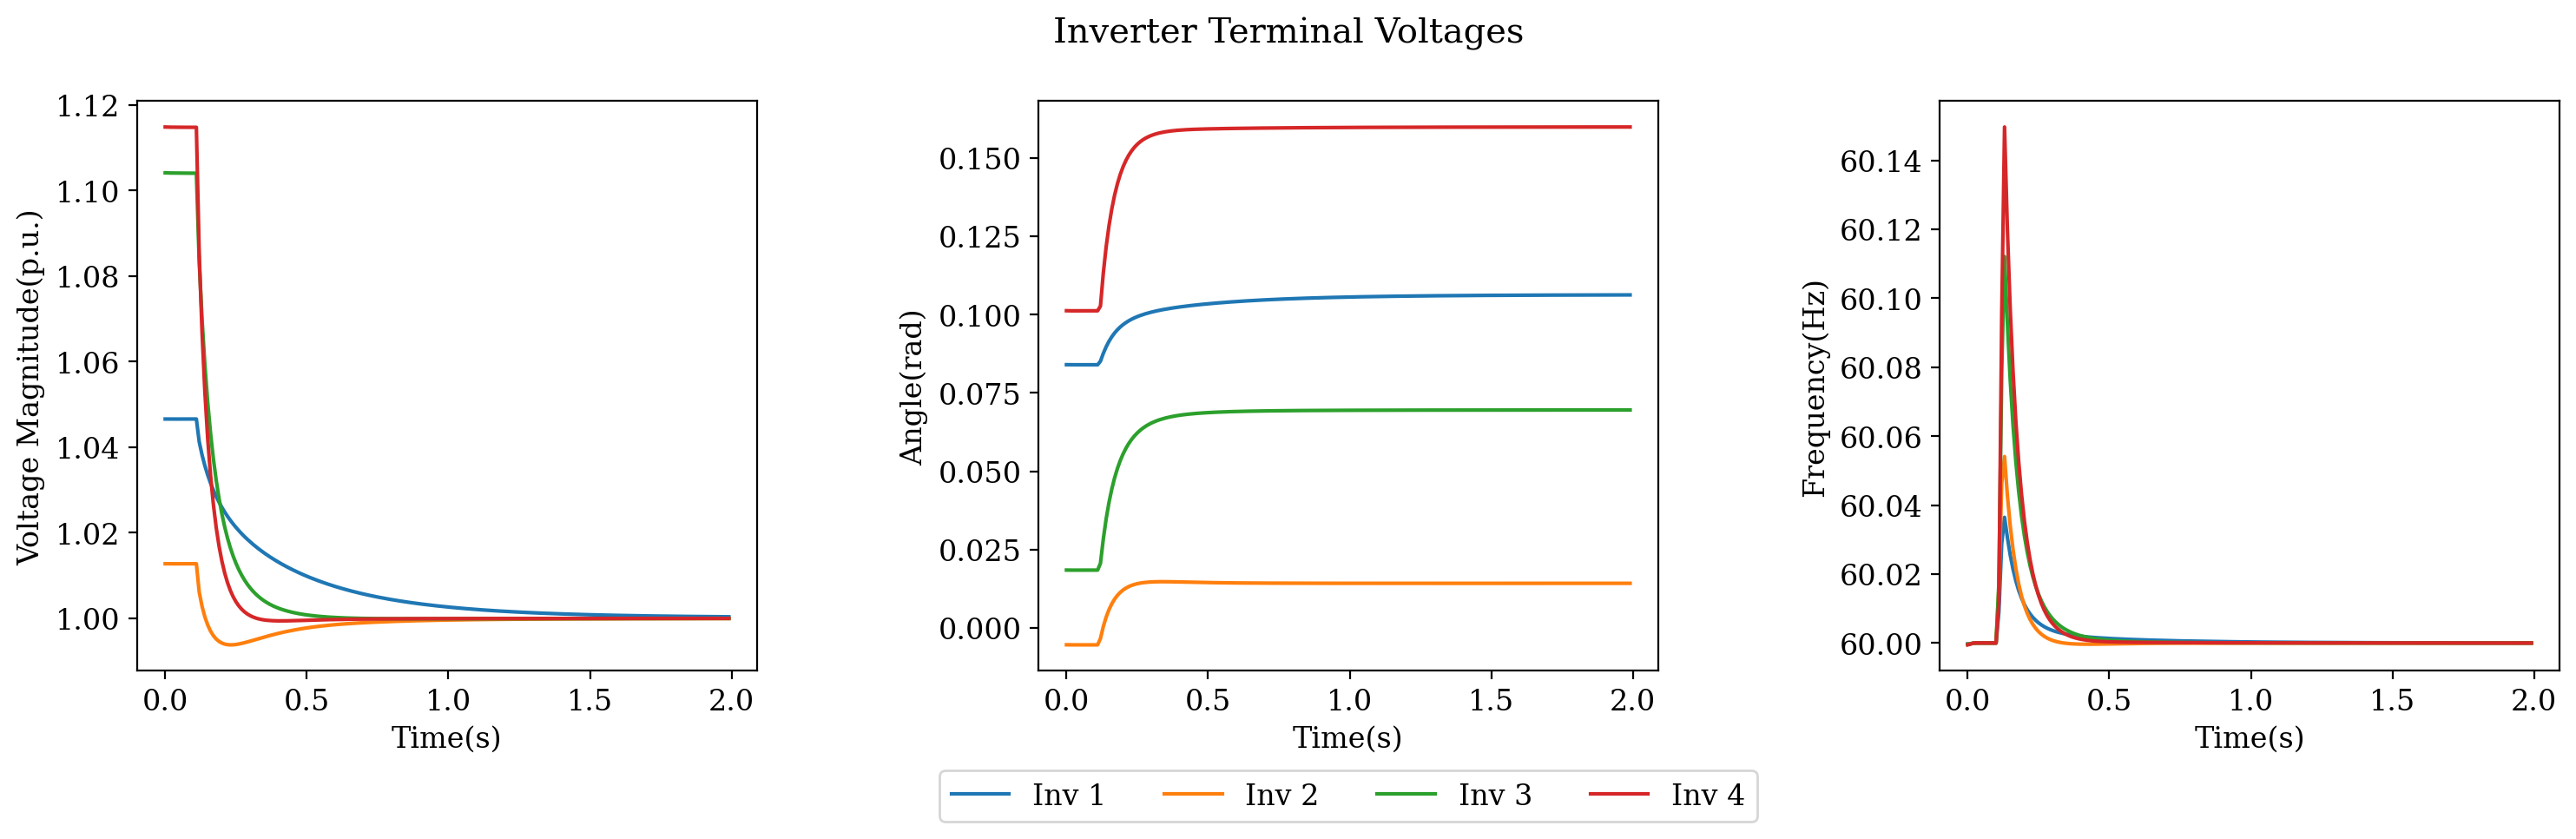

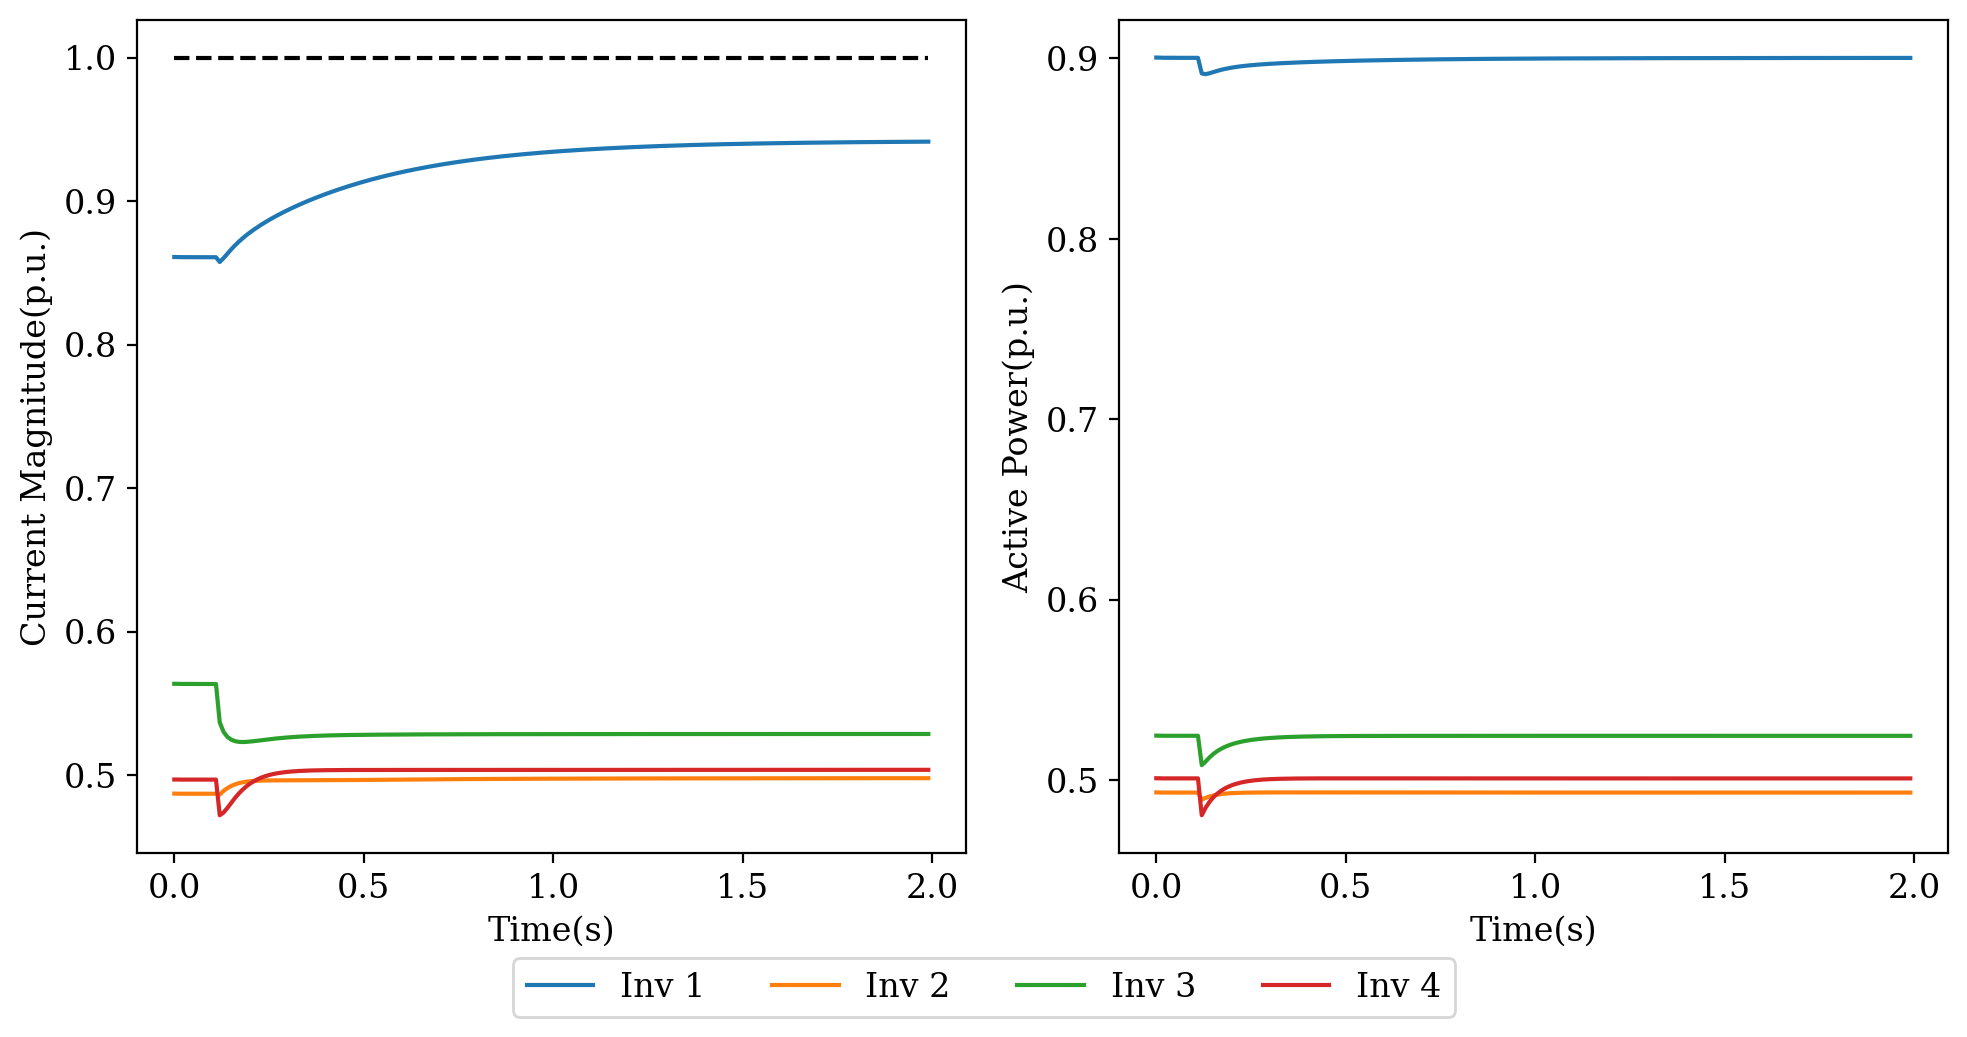

In [28]:
starttime=0.1
endtime = 2
dt = 1e-2
rho = 0.0001
alpha = 2

Ps0, Qs0, V2s0 = mc.initial_setpoints(slack_id, inverter_bus_ids, pf_result,Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs)

gen_mask = np.isin(pf_result["gen"][:,GEN_BUS], inverter_bus_ids)
inverter_setpoints = np.vstack((Ps0, V2s0)).T
inverter_setpoints[:,1] = np.array([1,1,1,1])
inverter_varnames = np.array([["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"]]) # variables corresponding to setpoints in above array
inverter_mag_limits = np.ones(len(inverter_bus_ids)) # all limited to 1 pu? check what this value should be - possibly smaller since baseMVA is large

ts, Iinvs, Vinvs, Vgs, Ps, Qs = mc.multi_inv_simulation(slack_id, inverter_bus_ids, inverter_setpoints, inverter_varnames, 
                         inverter_mag_limits, pf_result, 
                         Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs,
                         rho=rho, alpha=alpha,
                         dt=dt, starttime = starttime, endtime=endtime)

# Plot voltage magnitude, angle, and frequency (network voltages)
n_steps = len(ts)
n_inv = len(inverter_bus_ids)
Vg_mag_data = np.linalg.norm(Vgs.reshape(n_steps,n_inv,2),axis=2)
Vg_angle_data, Vg_frequency_data = plot.angle_and_frequency(Vgs, dt)
Vg_frequency_data = (Vg_frequency_data+2*np.pi*60)/(2*np.pi) # convert to rotating frame and to Hz
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,5), sharex=True)
plot.plot_multi_inverters(ts, Vg_mag_data, "Voltage Magnitude(p.u.)", "Bus", xlim=None, inv_labels = None, ax=ax1, show_legend=False)
plot.plot_multi_inverters(ts, Vg_angle_data, "Angle(rad)", "Bus", xlim=None, inv_labels = None, ax=ax2, show_legend=True)
plot.plot_multi_inverters(ts, Vg_frequency_data, "Frequency(Hz)", "Bus", xlim=None, inv_labels = None, ax=ax3, show_legend=False)
plt.tight_layout()
plt.show()

Vi_mag_data = np.linalg.norm(Vinvs.reshape(n_steps,n_inv,2),axis=2)
Vi_angle_data, Vi_frequency_data = plot.angle_and_frequency(Vinvs, dt)
Vi_frequency_data = (Vi_frequency_data+2*np.pi*60)/(2*np.pi) # convert to rotating frame and to Hz
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,5), sharex=True)
plot.plot_multi_inverters(ts, Vi_mag_data, "Voltage Magnitude(p.u.)", "Inv", xlim=None, inv_labels = None, ax=ax1, show_legend=False)
plot.plot_multi_inverters(ts, Vi_angle_data, "Angle(rad)", "Inv", xlim=None, inv_labels = None, ax=ax2, show_legend=True)
plot.plot_multi_inverters(ts, Vi_frequency_data, "Frequency(Hz)", "Inv", xlim=None, inv_labels = None, ax=ax3, show_legend=False)
fig.suptitle("Inverter Terminal Voltages")
plt.tight_layout()
plt.show()

Ii_mag_data = np.linalg.norm(Iinvs.reshape(n_steps,n_inv,2),axis=2)
Ps_setpoints = np.ones((len(ts), n_inv)) * inverter_setpoints[:,0]
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5), sharex=True)
ax1.plot(ts, np.ones(len(ts)), "k--") # Plot current limit
plot.plot_multi_inverters(ts, Ii_mag_data, "Current Magnitude(p.u.)", "Inv", xlim=None, inv_labels = None, ax=ax1, show_legend=False)
plot.plot_multi_inverters(ts, Ps, "Active Power(p.u.)", "Inv", xlim=None, inv_labels = None, ax=ax2, show_legend=False)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_inv, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

#### 4. Example 2: Increase power setpoint for inverter 1 to violate current limit

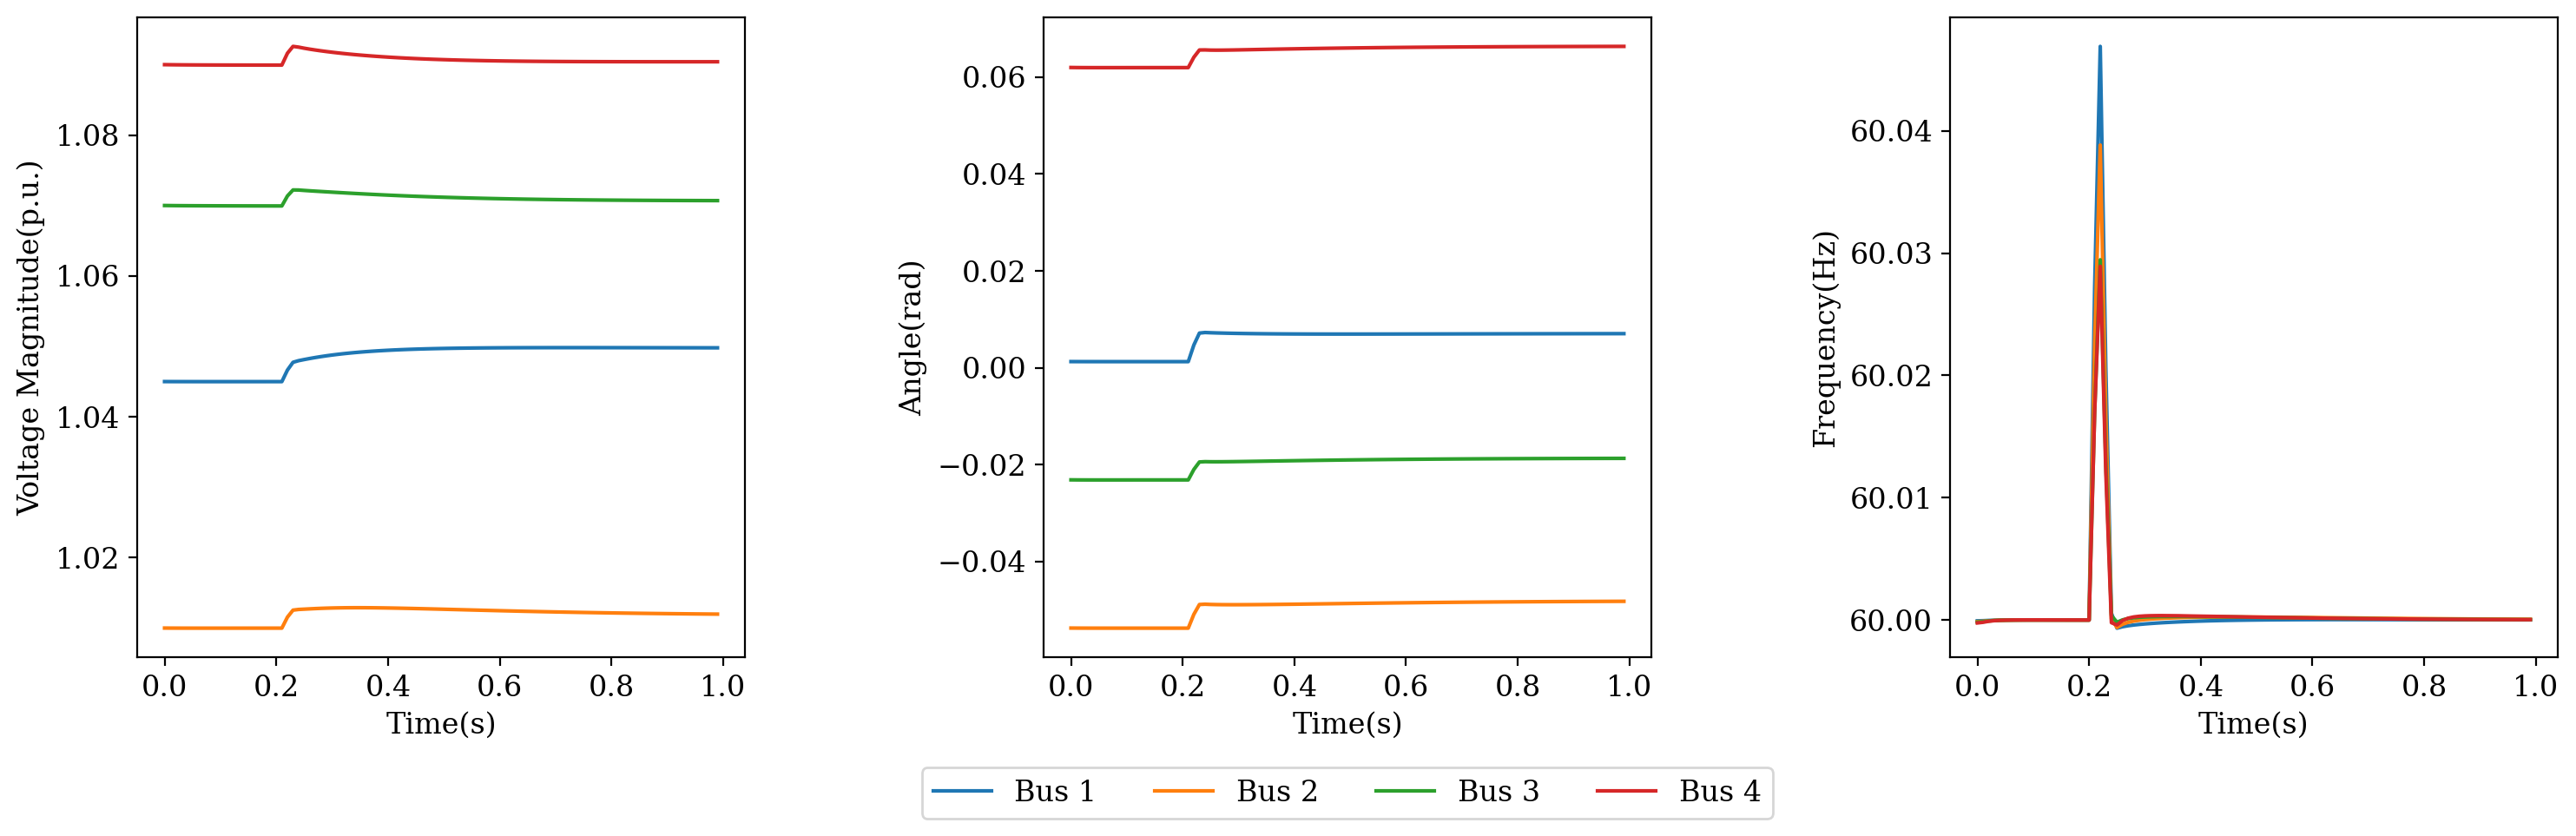

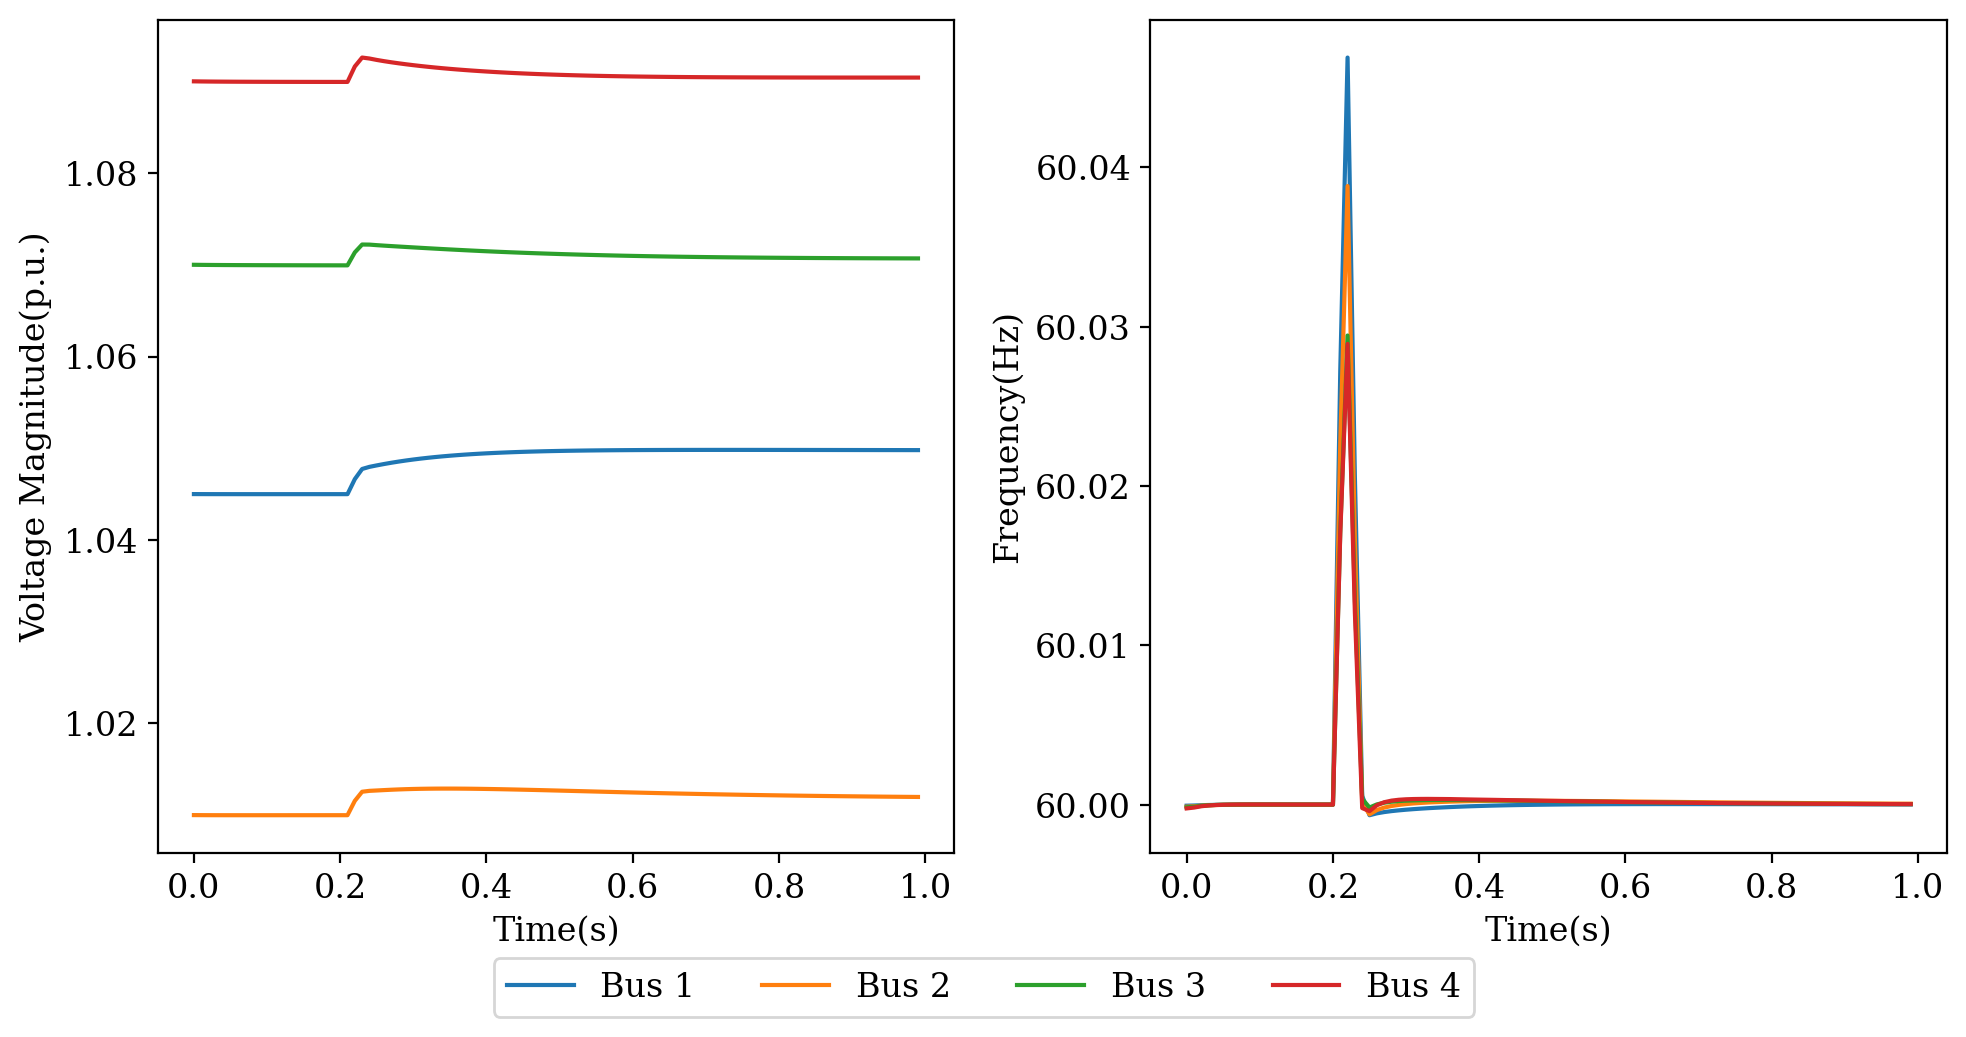

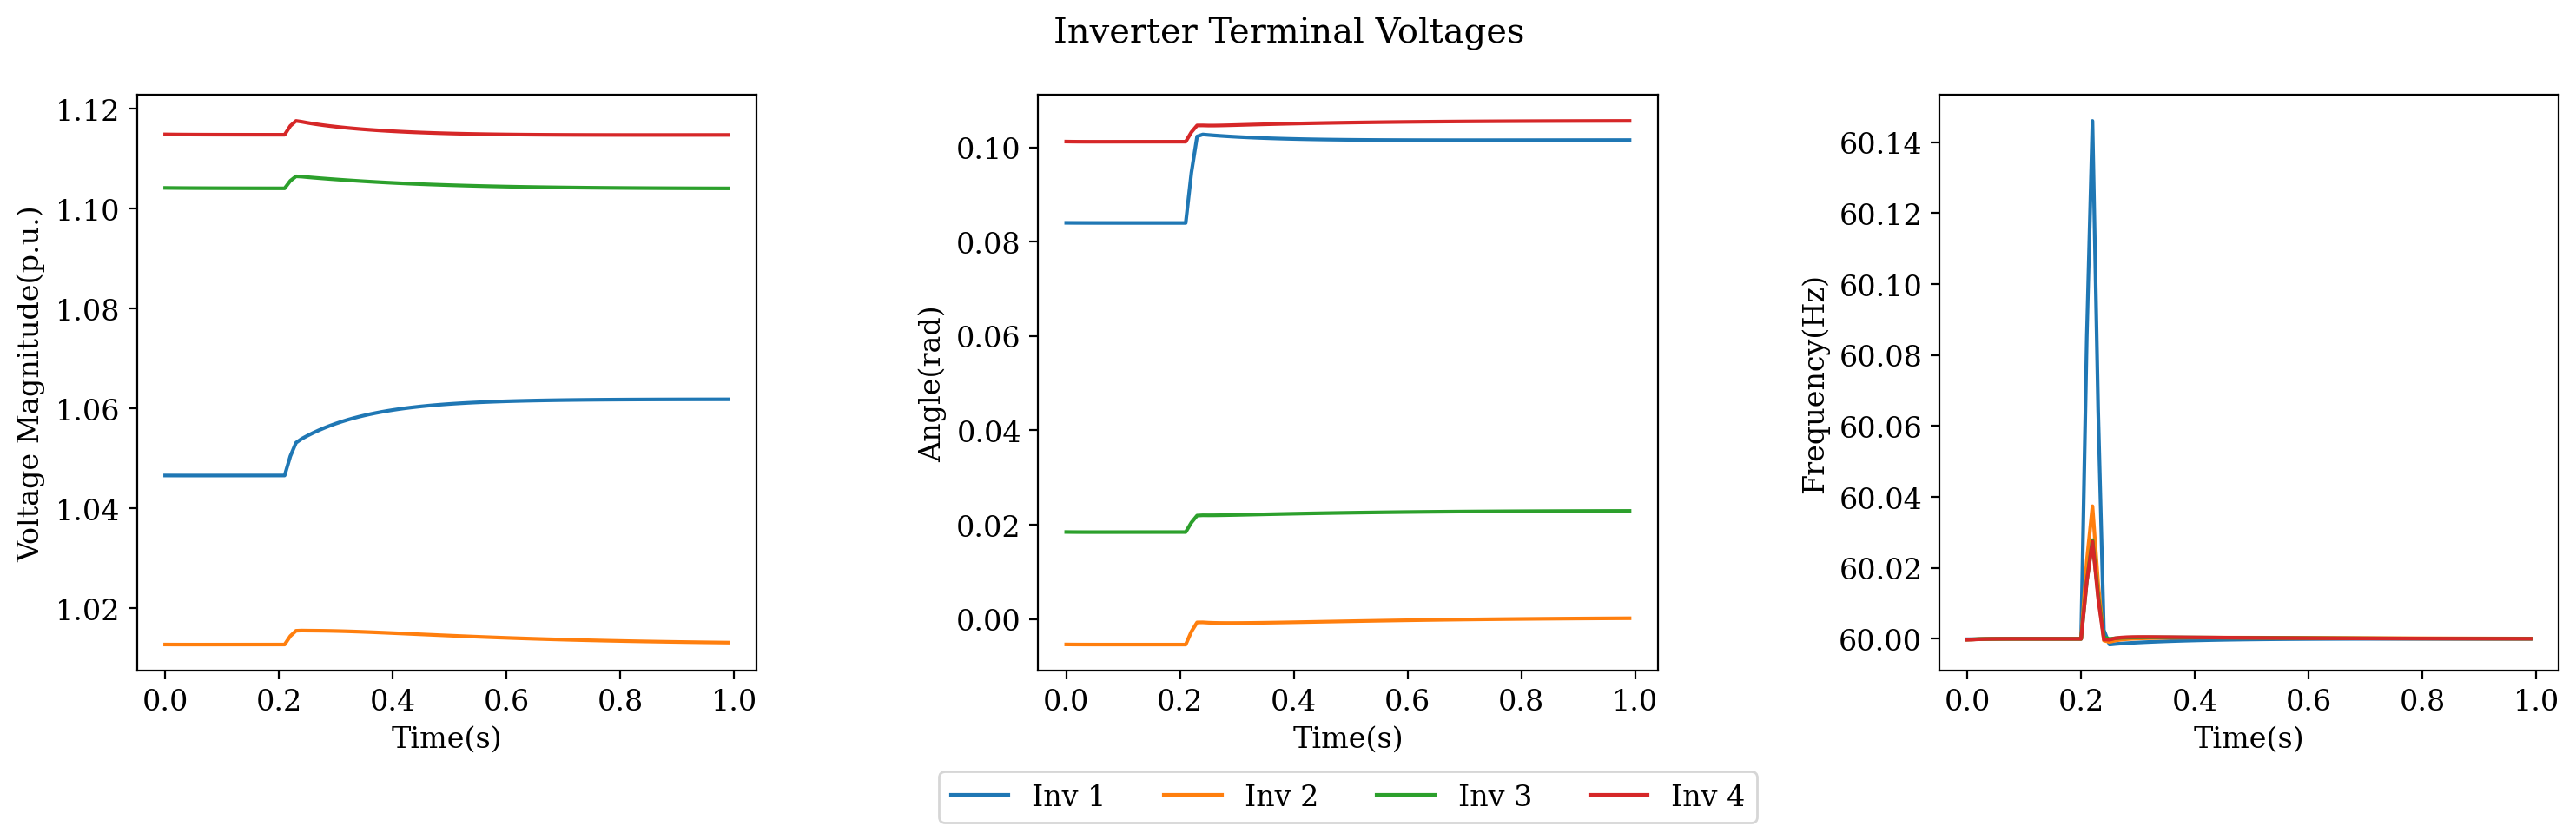

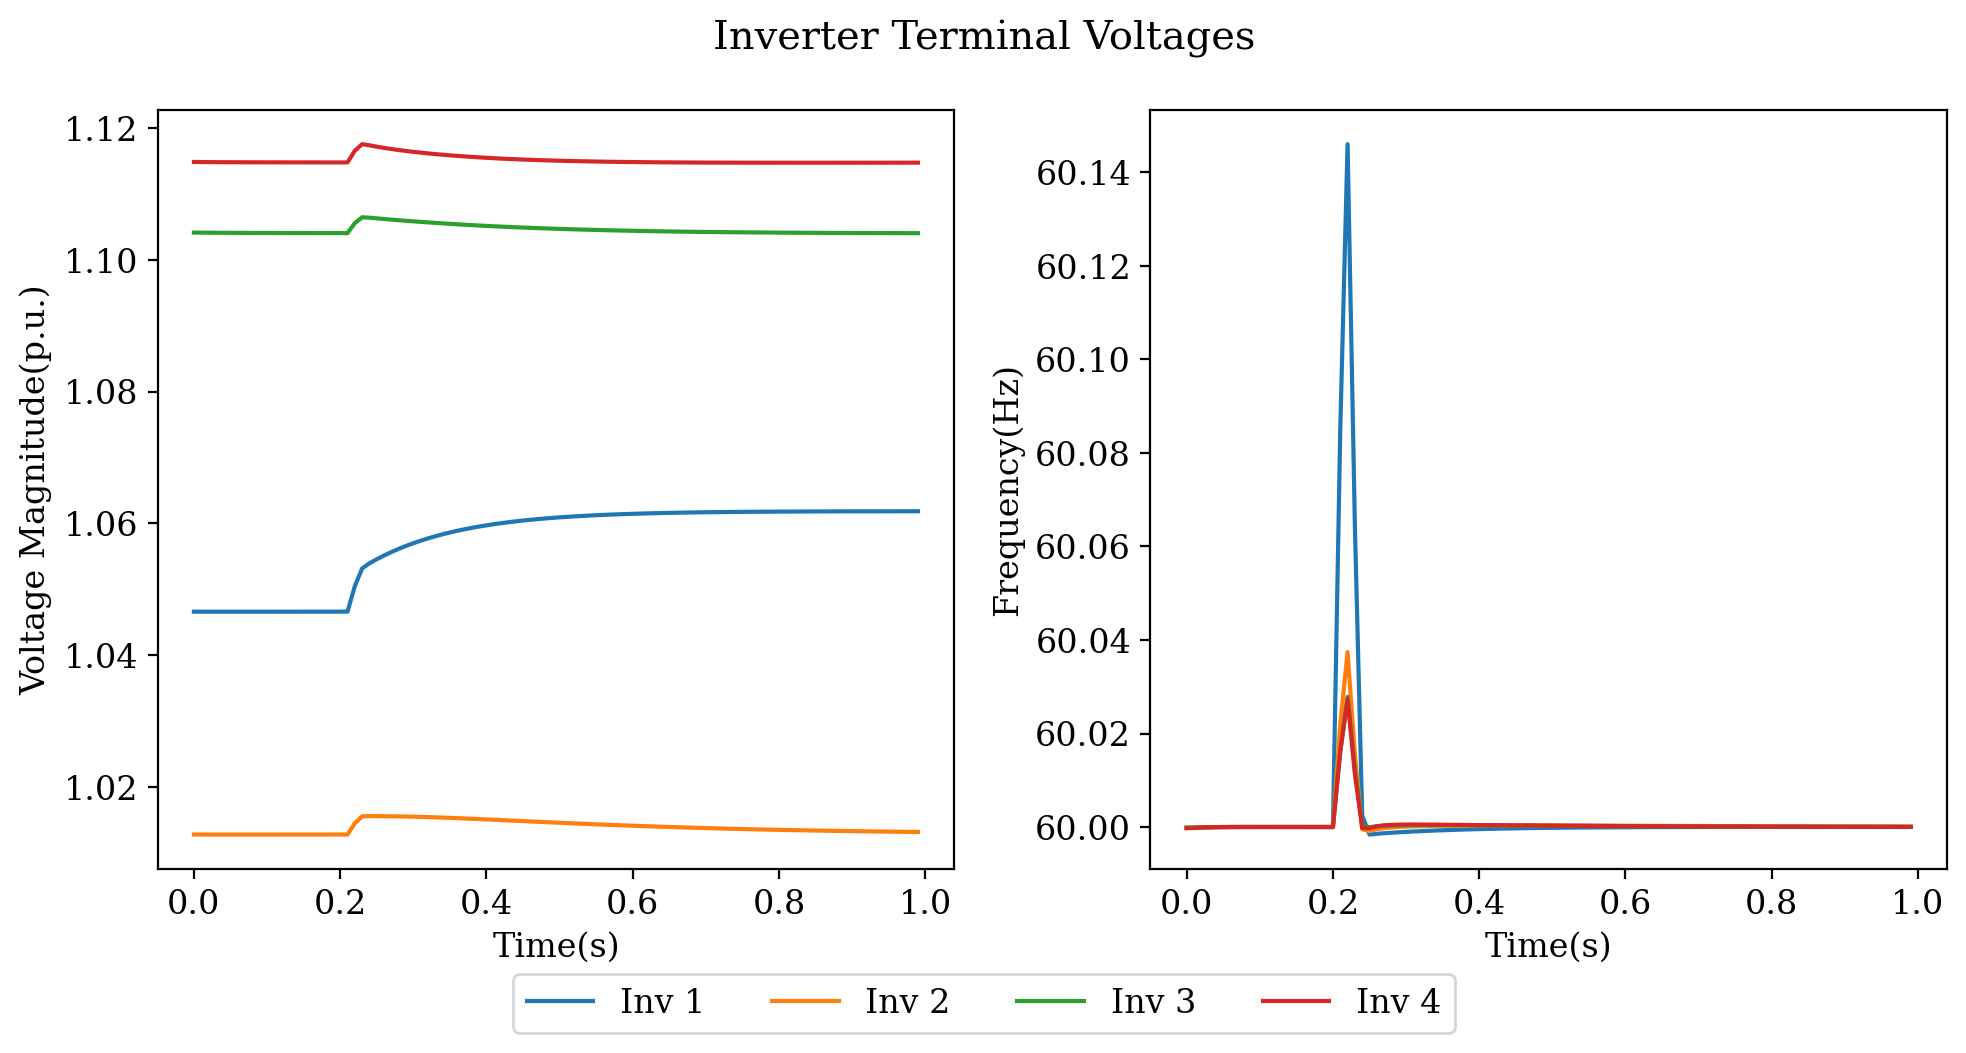

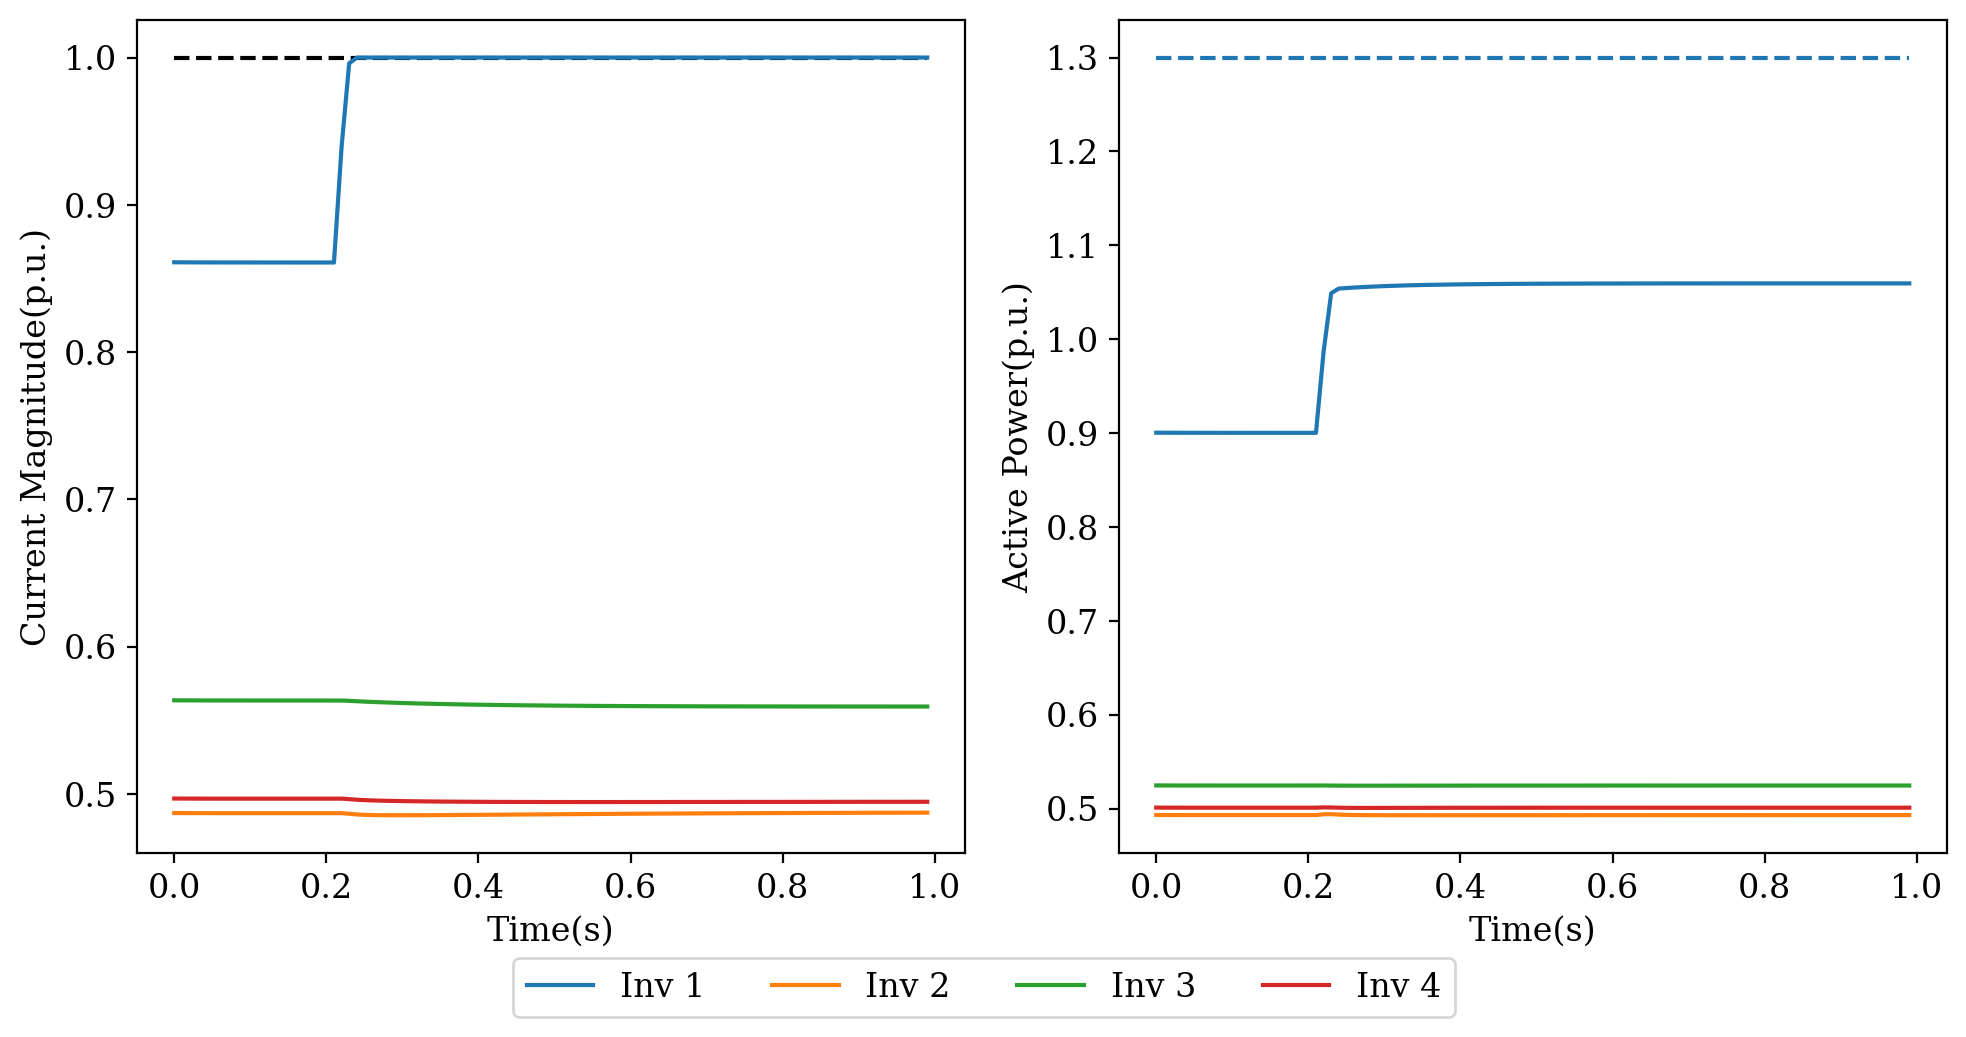

In [39]:
starttime=0.2
endtime = 1
dt = 1e-2
rho = 0.0001
alpha = 1

Ps0, Qs0, V2s0 = mc.initial_setpoints(slack_id, inverter_bus_ids, pf_result,Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs)

gen_mask = np.isin(pf_result["gen"][:,GEN_BUS], inverter_bus_ids)
inverter_setpoints = np.vstack((Ps0, V2s0)).T
inverter_setpoints[0,0] = 1.3
inverter_varnames = np.array([["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"]]) # variables corresponding to setpoints in above array
inverter_mag_limits = np.ones(len(inverter_bus_ids)) # all limited to 1 pu? check what this value should be - possibly smaller since baseMVA is large

ts, Iinvs, Vinvs, Vgs, Ps, Qs = mc.multi_inv_simulation(slack_id, inverter_bus_ids, inverter_setpoints, inverter_varnames, 
                         inverter_mag_limits, pf_result, 
                         Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs,
                         rho=rho, alpha=alpha,
                         dt=dt, starttime = starttime, endtime=endtime)

# Plot voltage magnitude, angle, and frequency (network voltages)
n_steps = len(ts)
n_inv = len(inverter_bus_ids)
Vg_mag_data = np.linalg.norm(Vgs.reshape(n_steps,n_inv,2),axis=2)
Vg_angle_data, Vg_frequency_data = plot.angle_and_frequency(Vgs, dt)
Vg_frequency_data = (Vg_frequency_data+2*np.pi*60)/(2*np.pi) # convert to rotating frame and to Hz
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,5), sharex=True)
plot.plot_multi_inverters(ts, Vg_mag_data, "Voltage Magnitude(p.u.)", "Bus", xlim=None, inv_labels = None, ax=ax1, show_legend=False)
plot.plot_multi_inverters(ts, Vg_angle_data, "Angle(rad)", "Bus", xlim=None, inv_labels = None, ax=ax2, show_legend=True)
plot.plot_multi_inverters(ts, Vg_frequency_data, "Frequency(Hz)", "Bus", xlim=None, inv_labels = None, ax=ax3, show_legend=False)
plt.tight_layout()
plt.show()

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5), sharex=True)
plot.plot_multi_inverters(ts, Vg_mag_data, "Voltage Magnitude(p.u.)", "Bus", xlim=None, inv_labels = None, ax=ax1, show_legend=False)
plot.plot_multi_inverters(ts, Vg_frequency_data, "Frequency(Hz)", "Bus", xlim=None, inv_labels = None, ax=ax2, show_legend=False)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_inv, bbox_to_anchor=(0.5, -0.05))
#plt.xlim(0.18,0.25)
plt.tight_layout()
plt.show()

Vi_mag_data = np.linalg.norm(Vinvs.reshape(n_steps,n_inv,2),axis=2)
Vi_angle_data, Vi_frequency_data = plot.angle_and_frequency(Vinvs, dt)
Vi_frequency_data = (Vi_frequency_data+2*np.pi*60)/(2*np.pi) # convert to rotating frame and to Hz
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,5), sharex=True)
plot.plot_multi_inverters(ts, Vi_mag_data, "Voltage Magnitude(p.u.)", "Inv", xlim=None, inv_labels = None, ax=ax1, show_legend=False)
plot.plot_multi_inverters(ts, Vi_angle_data, "Angle(rad)", "Inv", xlim=None, inv_labels = None, ax=ax2, show_legend=True)
plot.plot_multi_inverters(ts, Vi_frequency_data, "Frequency(Hz)", "Inv", xlim=None, inv_labels = None, ax=ax3, show_legend=False)
fig.suptitle("Inverter Terminal Voltages")
plt.tight_layout()
plt.show()

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5), sharex=True)
plot.plot_multi_inverters(ts, Vi_mag_data, "Voltage Magnitude(p.u.)", "Inv", xlim=None, inv_labels = None, ax=ax1, show_legend=False)
plot.plot_multi_inverters(ts, Vi_frequency_data, "Frequency(Hz)", "Inv", xlim=None, inv_labels = None, ax=ax2, show_legend=False)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_inv, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Inverter Terminal Voltages")
plt.tight_layout()
plt.show()

Ii_mag_data = np.linalg.norm(Iinvs.reshape(n_steps,n_inv,2),axis=2)
Ps_setpoints = np.ones((len(ts), n_inv)) * inverter_setpoints[:,0]
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5), sharex=True)
ax1.plot(ts, np.ones(len(ts)), "k--") # Plot current limit
plot.plot_multi_inverters(ts, Ii_mag_data, "Current Magnitude(p.u.)", "Inv", xlim=None, inv_labels = None, ax=ax1, show_legend=False)
ax2.plot(ts, inverter_setpoints[0,0] * np.ones(len(ts)), color="C0", linestyle="--") # Plot power setpoint 
plot.plot_multi_inverters(ts, Ps, "Active Power(p.u.)", "Inv", xlim=None, inv_labels = None, ax=ax2, show_legend=False)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_inv, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()